# OBJECTIVE

 # Identify why customers are leaving (churn) and give actionable business solutions

In [ ]:
# What is the overall churn rate? 
# Which country (Geography) has highest churn?
# Does Gender affect churn?
# Which age group churns the most?
# Does credit score impact churn?
# Are customers with higher balance more likely to churn?
# Does number of products affect churn?
# Are inactive members more likely to leave?
# Does salary influence churn?
# Does having a credit card affect churn?
_______




In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df =pd.read_csv("C:/Users/raza0/Downloads/Bank_Churn.csv")
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# 1) What is the overall churn rate? 

In [6]:
df["Exited"].value_counts()
df["Exited"].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

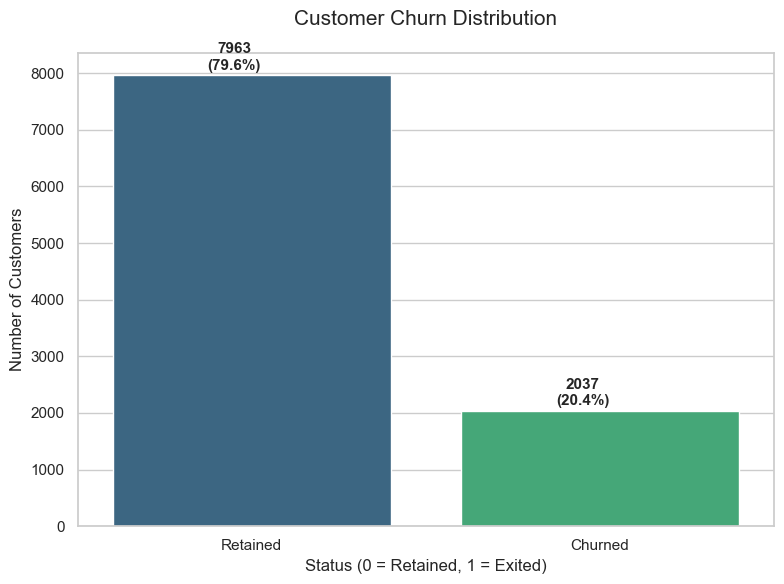

In [8]:
# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Create the countplot with a specific palette
ax = sns.countplot(x="Exited", data=df, palette="viridis")

# Add informative labels and title
plt.title("Customer Churn Distribution", fontsize=15, pad=20)
plt.xlabel("Status (0 = Retained, 1 = Exited)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks([0, 1], ['Retained', 'Churned']) # Replacing 0/1 with text

# Add percentage and count labels on top of each bar
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + (total * 0.01) # Small offset above the bar
    ax.annotate(f'{int(p.get_height())}\n({percentage})', (x, y), 
                ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# INSIGHTS = Majority of customers are retained, but churn segment is significant enough to require analysis.

# 2)  Which country (Geography) has highest churn?

In [13]:
df.groupby("Geography")["Exited"].mean()*100

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

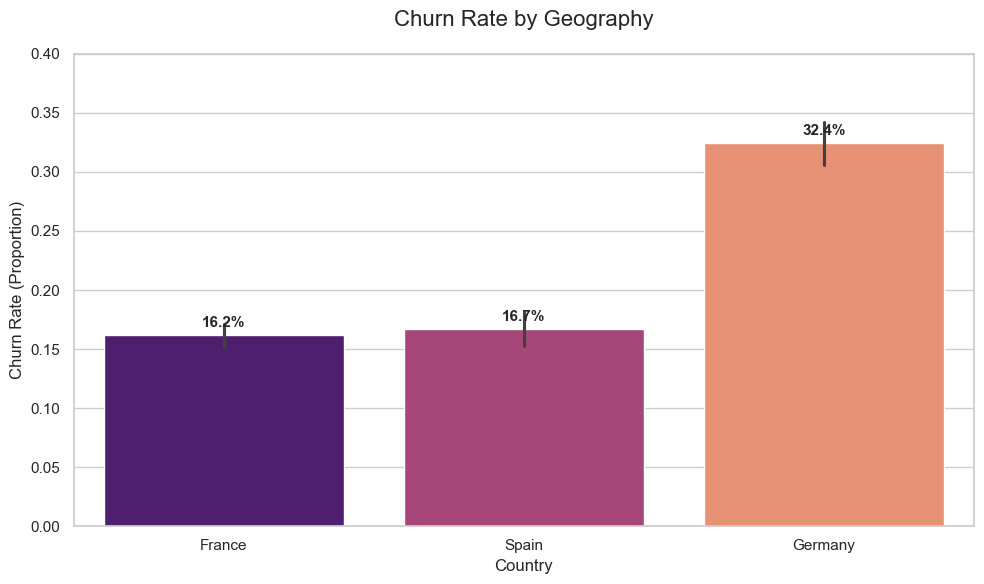

In [15]:
# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the barplot
# CI=None removes the error bars if you want a cleaner look, 
# but keeping them (default) shows the confidence interval.
ax = sns.barplot(x="Geography", y="Exited", data=df, palette="magma", hue="Geography", legend=False)

# Detailing the text
plt.title("Churn Rate by Geography", fontsize=16, pad=20)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Churn Rate (Proportion)", fontsize=12)
plt.ylim(0, 0.4) # Adjust based on your data (Germany is ~0.32)

# Adding percentage labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# INSIGHTS = Germany shows the highest churn rate among all regions, indicating possible dissatisfaction or competitive pressure in that market. The bank should investigate region-specific issues such as service quality or product offerings.

# 3) # Does Gender affect churn?

In [16]:
df.groupby("Gender")["Exited"].mean()*100

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

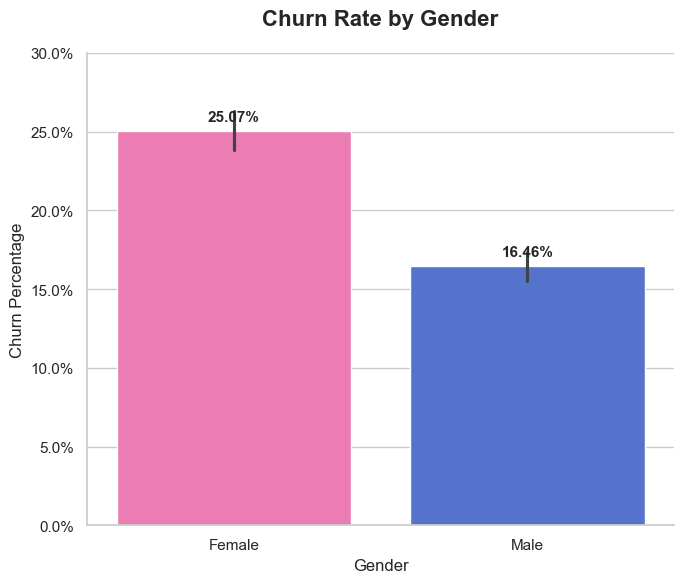

In [19]:
# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 6))

# Define colors
colors = ["#FF69B4", "#4169E1"] 

# Create the barplot
ax = sns.barplot(x="Gender", y="Exited", data=df, palette=colors, hue="Gender", legend=False)

# --- THE FIX FOR Y-AXIS ---
# 1. Set the limit clearly (0 to 0.30 covers your ~25% max)
plt.ylim(0, 0.30) 

# 2. Use a PercentFormatter to automatically turn 0.25 into 25%
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# ---------------------------

plt.title("Churn Rate by Gender", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Churn Percentage", fontsize=12)

# Add labels on top
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

# INSIGHTS = Female customers have a higher churn rate compared to males, suggesting potential differences in satisfaction or service expectations.

# 4) # Which age group churns the most?

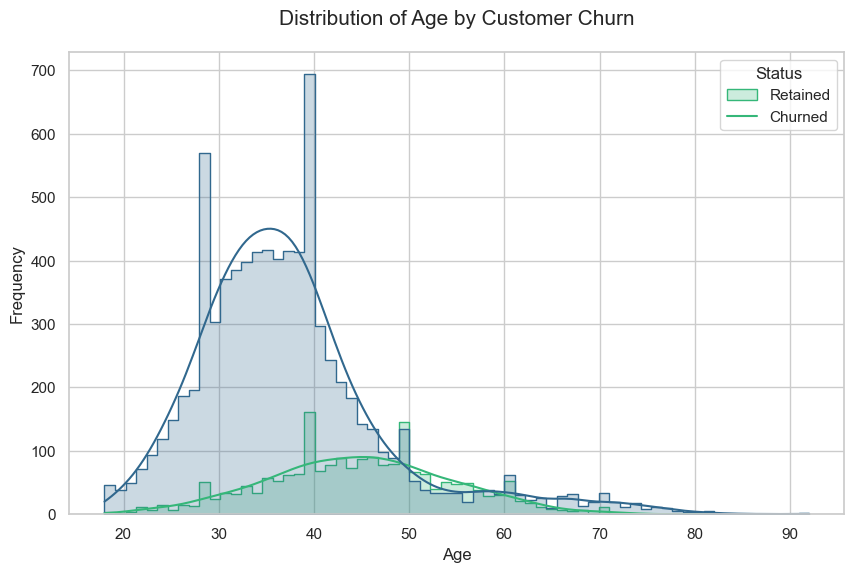

In [27]:
plt.figure(figsize=(10, 6))

# Use 'hue' to separate the data by the Exited status
sns.histplot(data=df, x="Age", hue="Exited", kde=True, element="step", palette="viridis")

# Customizing the labels
plt.title("Distribution of Age by Customer Churn", fontsize=15, pad=20)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(title="Status", labels=['Retained', 'Churned'])

plt.show()





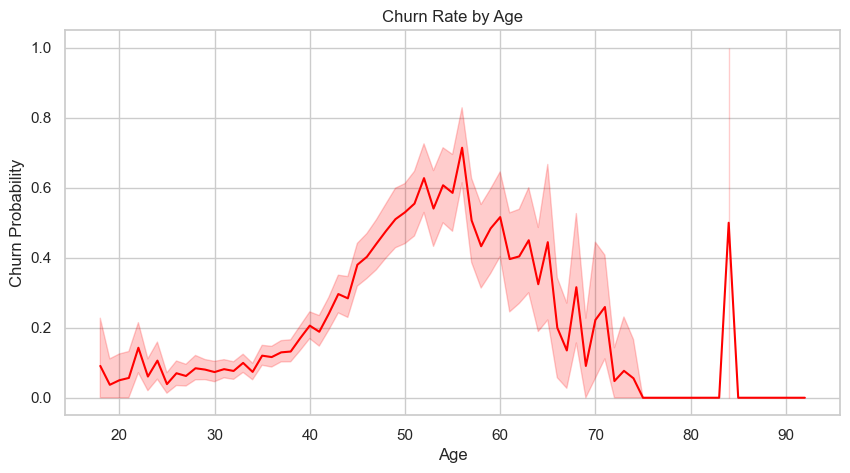

In [29]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x="Age", y="Exited", color="red")
plt.title("Churn Rate by Age")
plt.ylabel("Churn Probability")
plt.show()

 # INSIGHTS = "The typical churner is not a dissatisfied youth, but a 45-60 year old customer, specifically more prevalent in the German market and among female clients. Retention efforts should shift from broad marketing to targeted financial products for the 40+ demographic to stabilize this 'leaky' high-value segment."

  #  5 ) Does credit score impact churn?

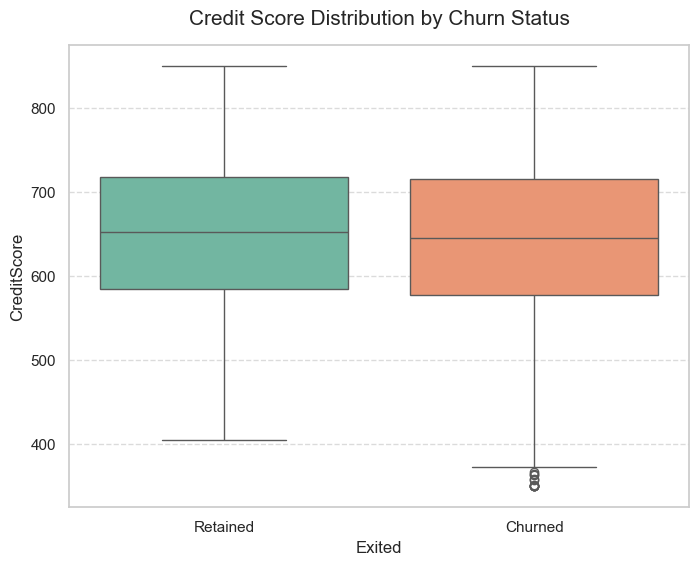

In [33]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Exited", y="CreditScore", palette="Set2", hue="Exited", legend=False)

plt.title("Credit Score Distribution by Churn Status", fontsize=15, pad=15)
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# INSIGHTS = The median credit scores for both "Retained" and "Churned" customers are nearly identical (around 650), suggesting Credit Score is not a primary driver of churn.

# 6) Are customers with higher balance more likely to churn?

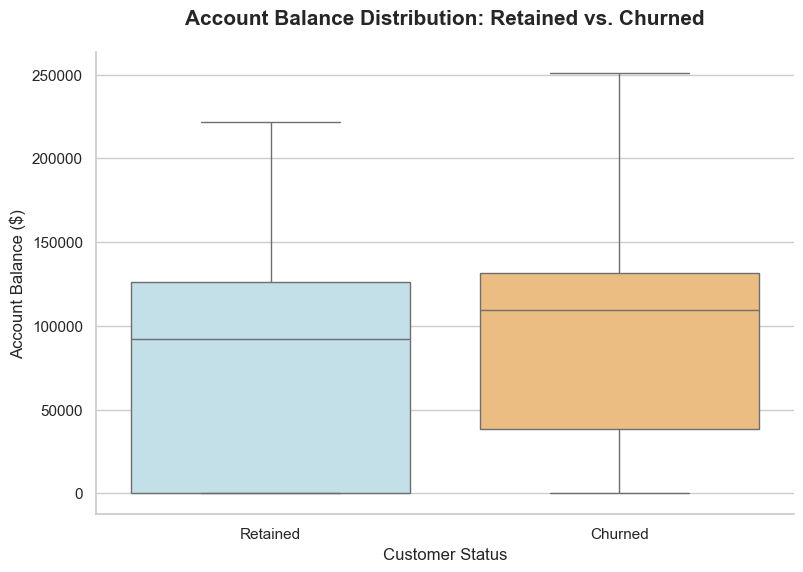

In [35]:
# Set the visual theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# Create the boxplot with a custom palette
# 'Exited' 0 = Retained (Blue), 1 = Churned (Orange/Red)
ax = sns.boxplot(data=df, x="Exited", y="Balance", palette="RdYlBu_r", hue="Exited", legend=False)

# Detailing the titles and labels
plt.title("Account Balance Distribution: Retained vs. Churned", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Customer Status", fontsize=12)
plt.ylabel("Account Balance ($)", fontsize=12)

# Changing 0/1 to clear text labels
plt.xticks([0, 1], ['Retained', 'Churned'])

# Clean up the top and right borders
sns.despine()

plt.show()

# This tells us that customers with higher balances are more likely to leave the bank.Customers with a 0 balance are ironically more "loyal" (or simply inactive) than those with money in the bank.

# 7) Does number of products affect churn?

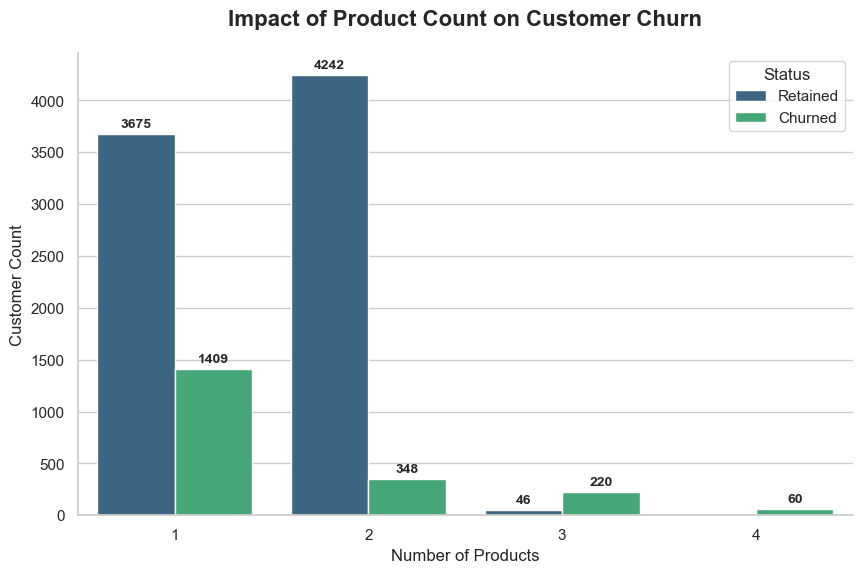

In [39]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create the countplot
ax = sns.countplot(data=df, x="NumOfProducts", hue="Exited", palette="viridis")

# Add detailing
plt.title("Impact of Product Count on Customer Churn", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Number of Products", fontsize=12)
plt.ylabel("Customer Count", fontsize=12)
plt.legend(title="Status", labels=['Retained', 'Churned'])

# Add count and percentage labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Avoid labeling empty bars
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 7), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

sns.despine()
plt.show()

In [4]:
# Calculating exact churn percentages per Product Count
churn_stats = df.groupby('NumOfProducts')['Exited'].value_counts(normalize=True).unstack() * 100
churn_stats.columns = ['Retained_%', 'Churned_%']
print(churn_stats)

               Retained_%   Churned_%
NumOfProducts                        
1               72.285602   27.714398
2               92.418301    7.581699
3               17.293233   82.706767
4                     NaN  100.000000


# two products represent the ideal "sweet spot" with a remarkably low churn rate of 7.6%. While single-product users pose a moderate risk at 27.7% churn due to lower brand integration, the most alarming insight is the "Product Overload" effect: customers with three or four products face an extreme churn probability of 82.7% to 100%.

# 8) Are inactive members more likely to leave?

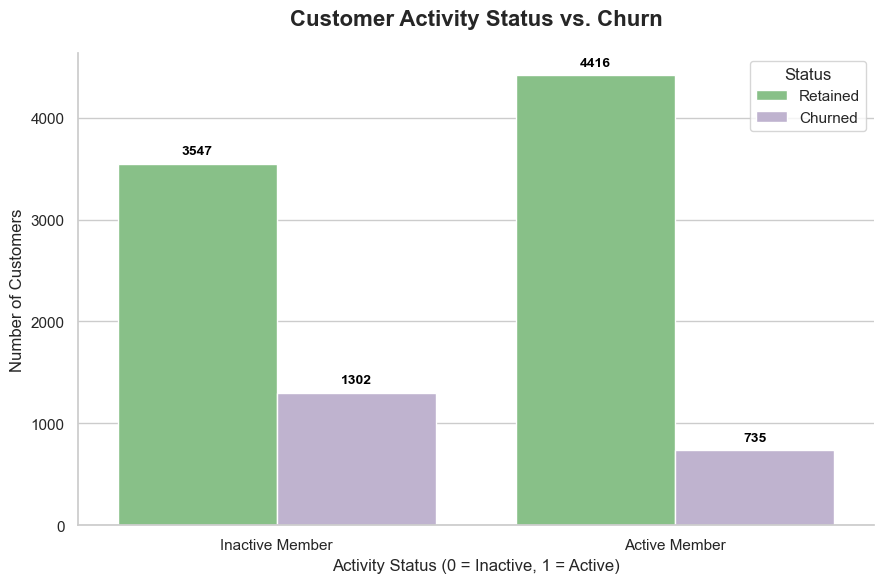

In [8]:
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# Create the countplot with a professional palette
ax = sns.countplot(data=df, x="IsActiveMember", hue="Exited", palette="Accent")

# Add detailing
plt.title("Customer Activity Status vs. Churn", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Activity Status (0 = Inactive, 1 = Active)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks([0, 1], ['Inactive Member', 'Active Member'])
plt.legend(title="Status", labels=['Retained', 'Churned'], frameon=True)

# Add value labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='black')

sns.despine()
plt.tight_layout()
plt.show()

In [9]:
# Calculate Churn Rate percentages for Active vs. Inactive members
activity_churn = df.groupby('IsActiveMember')['Exited'].value_counts(normalize=True).unstack() * 100
activity_churn.columns = ['Retained_%', 'Churned_%']
activity_churn.index = ['Inactive Member', 'Active Member']

print("Churn Percentage Breakdown:")
print(activity_churn.round(2))

Churn Percentage Breakdown:
                 Retained_%  Churned_%
Inactive Member       73.15      26.85
Active Member         85.73      14.27


# Active members are significantly more loyal, showing a churn rate of only 14.27%, whereas inactive members are nearly twice as likely to leave at 26.85%. While the bank has more active users overall,

# 9) # Does salary influence churn?


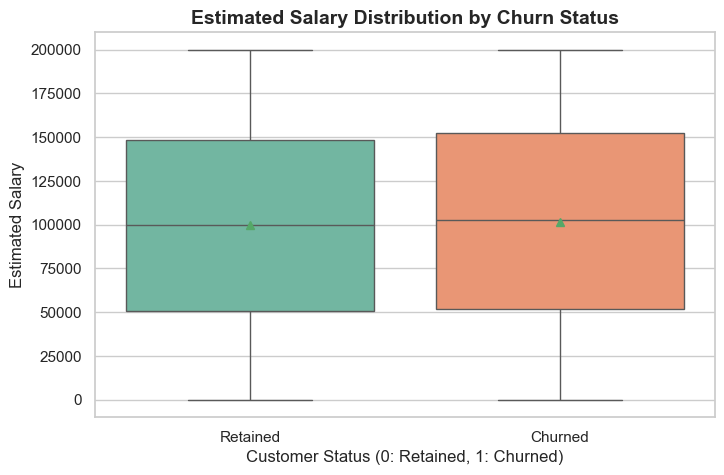

In [13]:
plt.figure(figsize=(8, 5))
# Adding showmeans=True to see the average salary point
sns.boxplot(data=df, x="Exited", y="EstimatedSalary", palette="Set2", showmeans=True)

plt.title("Estimated Salary Distribution by Churn Status", fontsize=14, fontweight='bold')
plt.xlabel("Customer Status (0: Retained, 1: Churned)", fontsize=12)
plt.ylabel("Estimated Salary", fontsize=12)
plt.xticks([0, 1], ['Retained', 'Churned'])

plt.show()

# Estimated Salary is not a strong predictor of churn. Whether a customer earns a high or low salary, their likelihood of leaving the bank remains relatively the same.

# 10)# Does having a credit card affect churn?

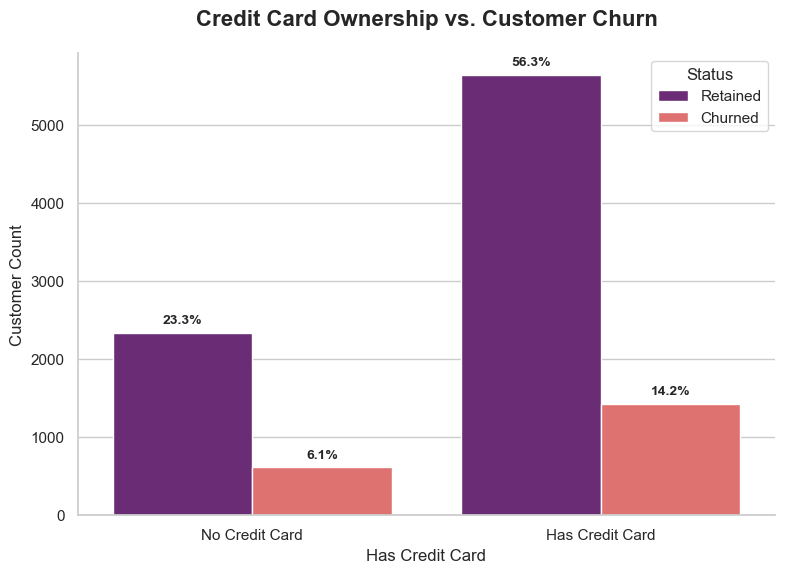

In [16]:
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(data=df, x="HasCrCard", hue="Exited", palette="magma")

plt.title("Credit Card Ownership vs. Customer Churn", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Has Credit Card", fontsize=12)
plt.ylabel("Customer Count", fontsize=12)
plt.xticks([0, 1], ['No Credit Card', 'Has Credit Card'])
plt.legend(title="Status", labels=['Retained', 'Churned'])

# FIXED: Calculating percentage relative to the total number of customers
total = len(df) 

for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Only label bars that have data
        # Calculate percentage of the total dataset
        percentage = (height / total) * 100
        ax.annotate(f'{percentage:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

sns.despine()
plt.show()

# churn percentage is nearly identical for both groups (around 20%). This confirms that Credit Card ownership is a "neutral" feature—it doesn't significantly help or hurt customer retention.